In [1]:
import torch
import random
import numpy as np

# --------------------------------------------------
# Reproducibility Seed
# --------------------------------------------------

seed = 42

random.seed(seed)
np.random.seed(seed)

torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

print("Random seed set for reproducibility.")

Random seed set for reproducibility.


# *Loading Data*

In [2]:
train = "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/train"
test = "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/test"
validation = "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/validation"

In [3]:
import os

def load_images_from_dirs(dir_list):
    all_images = []

    for directory in dir_list:
        for img in os.listdir(directory):
            img_path = os.path.join(directory, img)

            if os.path.isfile(img_path):
                all_images.append(img_path)

    return all_images

In [4]:
test_fake_dirs = [
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/test/Deepfakes",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/test/Face2Face",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/test/FaceShifter",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/test/FaceSwap",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/test/NeuralTextures"
]

test_real_dirs = [
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/test/real"
]

test_fake = load_images_from_dirs(test_fake_dirs)
test_real = load_images_from_dirs(test_real_dirs)

print(len(test_fake))
print(len(test_real))

2250
2250


In [5]:
train_fake_dirs = [
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/train/Deepfakes",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/train/Face2Face",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/train/FaceShifter",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/train/FaceSwap",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/train/NeuralTextures"
]

train_real_dirs = [
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/train/real"
]

train_fake = load_images_from_dirs(train_fake_dirs)
train_real = load_images_from_dirs(train_real_dirs)

print(len(train_fake))
print(len(train_real))

10500
10500


In [6]:
validation_fake_dirs = [
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/validation/Deepfakes",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/validation/Face2Face",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/validation/FaceShifter",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/validation/FaceSwap",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/validation/NeuralTextures"
]

validation_real_dirs = [
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/validation/real"
]

validation_fake = load_images_from_dirs(validation_fake_dirs)
validation_real = load_images_from_dirs(validation_real_dirs)

print(len(validation_fake))
print(len(validation_real))

2250
2250


# Data loaders 


In [7]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import time
import copy

class DeepfakeDataset(Dataset):
    def __init__(self, fake_paths, real_paths, transform=None):
        
        self.image_paths = fake_paths + real_paths
        self.labels = [1] * len(fake_paths) + [0] * len(real_paths)
        
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [8]:
IMG_SIZE = 299

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [9]:
train_dataset = DeepfakeDataset(
    train_fake,
    train_real,
    transform=train_transform
)

val_dataset = DeepfakeDataset(
    validation_fake,
    validation_real,
    transform=val_test_transform
)

test_dataset = DeepfakeDataset(
    test_fake,
    test_real,
    transform=val_test_transform
)

In [10]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

In [11]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

21000
4500
4500
torch.Size([32, 3, 299, 299])
torch.Size([32])


# *Train Model Function*

In [12]:
# ============================================================
# TRAINING FUNCTION
# ============================================================

def train_model(
    model,
    criterion,
    optimizer,
    train_loader,
    val_loader,
    num_epochs=25,
    patience=5,
    save_path="best_model.pth"
):

    since = time.time()

    # --------------------------------------------------------
    # AUTOMATIC DEVICE DETECTION
    # --------------------------------------------------------

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    model = model.to(device)

    # --------------------------------------------------------
    # BEST MODEL TRACKING
    # --------------------------------------------------------

    best_model_wts = copy.deepcopy(model.state_dict())

    best_acc = 0.0

    epochs_no_improve = 0

    early_stop = False

    # --------------------------------------------------------
    # HISTORY TRACKING
    # --------------------------------------------------------

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    # ========================================================
    # EPOCH LOOP
    # ========================================================

    for epoch in range(num_epochs):

        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # ====================================================
        # TRAIN + VALIDATION PHASES
        # ====================================================

        for phase in ['train', 'val']:

            if phase == 'train':

                model.train()

                dataloader = train_loader

            else:

                model.eval()

                dataloader = val_loader

            running_loss = 0.0

            running_corrects = 0

            # =================================================
            # ITERATE OVER DATA
            # =================================================

            for inputs, labels in dataloader:

                inputs = inputs.to(device)

                labels = labels.to(device)

                # --------------------------------------------
                # ZERO GRADIENTS
                # --------------------------------------------

                optimizer.zero_grad()

                # --------------------------------------------
                # FORWARD PASS
                # --------------------------------------------

                with torch.set_grad_enabled(
                    phase == 'train'
                ):

                    outputs = model(inputs)

                    _, preds = torch.max(
                        outputs,
                        1
                    )

                    loss = criterion(
                        outputs,
                        labels
                    )

                    # ----------------------------------------
                    # BACKWARD + OPTIMIZE
                    # ----------------------------------------

                    if phase == 'train':

                        loss.backward()

                        optimizer.step()

                # --------------------------------------------
                # STATISTICS
                # --------------------------------------------

                running_loss += (
                    loss.item() * inputs.size(0)
                )

                running_corrects += torch.sum(
                    preds == labels.data
                )

            # =================================================
            # EPOCH METRICS
            # =================================================

            epoch_loss = (
                running_loss / len(dataloader.dataset)
            )

            epoch_acc = (
                running_corrects.double()
                / len(dataloader.dataset)
            )

            print(
                f'{phase} Loss: '
                f'{epoch_loss:.4f} '
                f'Acc: {epoch_acc:.4f}'
            )

            history[f'{phase}_loss'].append(
                epoch_loss
            )

            history[f'{phase}_acc'].append(
                epoch_acc.item()
            )

            # =================================================
            # SAVE BEST MODEL
            # =================================================

            if phase == 'val':

                if epoch_acc > best_acc:

                    best_acc = epoch_acc

                    best_model_wts = copy.deepcopy(
                        model.state_dict()
                    )

                    epochs_no_improve = 0

                    # ----------------------------------------
                    # SAVE BEST MODEL
                    # ----------------------------------------

                    torch.save(
                        model.state_dict(),
                        save_path
                    )

                    print(
                        "Best model saved."
                    )

                else:

                    epochs_no_improve += 1

        # ====================================================
        # EARLY STOPPING
        # ====================================================

        if epochs_no_improve == patience:

            print(
                f'Early stopping triggered '
                f'after {patience} epochs '
                f'with no improvement '
                f'in validation accuracy.'
            )

            early_stop = True

            break

        # ====================================================
        # CLEAR CUDA CACHE
        # ====================================================

        torch.cuda.empty_cache()

    # ========================================================
    # TRAINING COMPLETE
    # ========================================================

    time_elapsed = time.time() - since

    print(
        f'Training complete in '
        f'{time_elapsed // 60:.0f}m '
        f'{time_elapsed % 60:.0f}s'
    )

    print(f'Best val Acc: {best_acc:.4f}')

    # ========================================================
    # LOAD BEST MODEL WEIGHTS
    # ========================================================

    model.load_state_dict(best_model_wts)

    return model, history

print(
    "Training function `train_model` defined. "
    "You can now call it normally."
)

Training function `train_model` defined. You can now call it normally.


# XceptionNet-41 Model — Baseline Model 7

In [13]:
import timm
import torch
import torch.nn as nn
import torch.optim as optim

# ============================================================
# XCEPTION41 MODEL SETUP
# 41-layer deeper variant of Xception
# Same 299×299 input — reuses existing train/val/test loaders
# ============================================================

print("Loading pretrained XceptionNet-41...")
model_xception41 = timm.create_model('xception41', pretrained=True)

# Freeze all layers first
for param in model_xception41.parameters():
    param.requires_grad = False

print("All XceptionNet-41 backbone layers frozen.")

# Unfreeze last 40 parameters (slightly more than original xception
# to account for the deeper architecture)
all_params = list(model_xception41.parameters())
for i, param in enumerate(all_params):
    if i >= len(all_params) - 40:
        param.requires_grad = True

print("Unfrozen the last 40 parameters for fine-tuning.")

# Get classifier input features
num_ftrs_xception41 = model_xception41.num_features

# Same 3-layer classifier head as original Xception baseline
model_xception41.head.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(num_ftrs_xception41, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, 2)
)

# Unfreeze classifier head explicitly
for param in model_xception41.head.fc.parameters():
    param.requires_grad = True

print(f"Custom 3-layer head attached (in_features={num_ftrs_xception41}).")

criterion_xception41 = nn.CrossEntropyLoss()
optimizer_xception41 = optim.Adam(
    filter(lambda p: p.requires_grad, model_xception41.parameters()),
    lr=0.0001
)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_xception41 = model_xception41.to(device)

print(f"XceptionNet-41 moved to: {device}")

trainable = sum(p.numel() for p in model_xception41.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_xception41.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")


Loading pretrained XceptionNet-41...


model.safetensors:   0%|          | 0.00/108M [00:00<?, ?B/s]

All XceptionNet-41 backbone layers frozen.
Unfrozen the last 40 parameters for fine-tuning.
Custom 3-layer head attached (in_features=2048).
XceptionNet-41 moved to: cuda:0
Trainable params: 10,607,106 / 26,035,570 (40.7%)


In [14]:
# XceptionNet-41 reuses the same 299x299 data loaders as original Xception
# (train_loader, val_loader, test_loader)

print("\n--- Starting XceptionNet-41 Training ---")

model_xception41_ft, hist_xception41 = train_model(
    model_xception41,
    criterion_xception41,
    optimizer_xception41,
    train_loader,
    val_loader,
    num_epochs=30,
    patience=5,
    save_path="best_xception41.pth"
)

print("\nTraining complete for XceptionNet-41.")
print("Best model saved to: best_xception41.pth")


--- Starting XceptionNet-41 Training ---
Epoch 1/30
----------
train Loss: 0.4989 Acc: 0.7384
val Loss: 0.4389 Acc: 0.8020
Best model saved.
Epoch 2/30
----------
train Loss: 0.2954 Acc: 0.8737
val Loss: 0.3969 Acc: 0.8349
Best model saved.
Epoch 3/30
----------
train Loss: 0.2227 Acc: 0.9111
val Loss: 0.3479 Acc: 0.8551
Best model saved.
Epoch 4/30
----------
train Loss: 0.1762 Acc: 0.9305
val Loss: 0.4268 Acc: 0.8449
Epoch 5/30
----------
train Loss: 0.1531 Acc: 0.9412
val Loss: 0.4680 Acc: 0.8331
Epoch 6/30
----------
train Loss: 0.1314 Acc: 0.9487
val Loss: 0.4978 Acc: 0.8536
Epoch 7/30
----------
train Loss: 0.1162 Acc: 0.9565
val Loss: 0.4469 Acc: 0.8638
Best model saved.
Epoch 8/30
----------
train Loss: 0.0967 Acc: 0.9635
val Loss: 0.5059 Acc: 0.8564
Epoch 9/30
----------
train Loss: 0.0949 Acc: 0.9633
val Loss: 0.4812 Acc: 0.8569
Epoch 10/30
----------
train Loss: 0.0823 Acc: 0.9690
val Loss: 0.3936 Acc: 0.8833
Best model saved.
Epoch 11/30
----------
train Loss: 0.0795 Acc: 

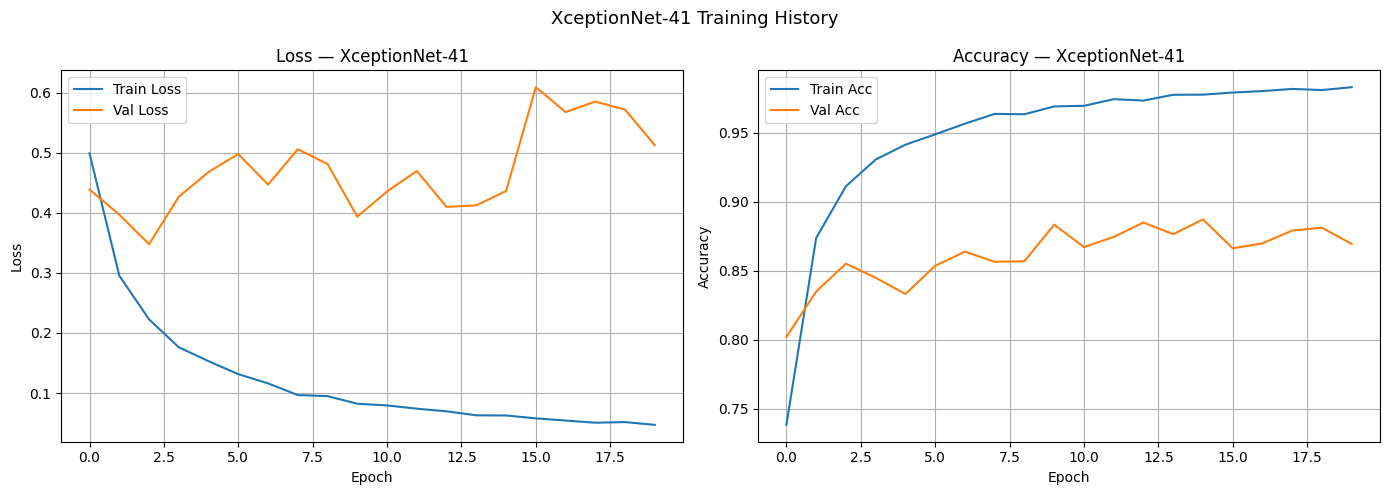


Evaluating XceptionNet-41 on test dataset...


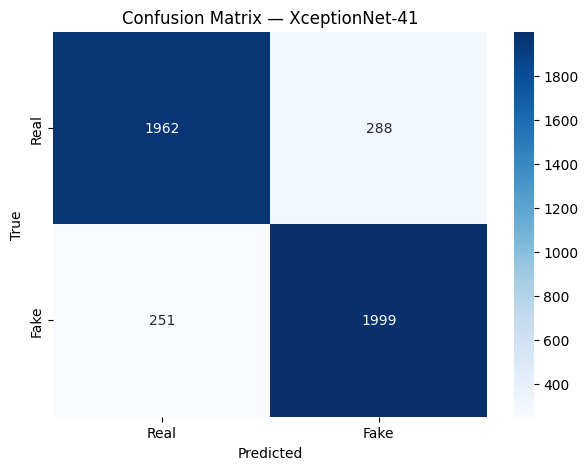


Test Accuracy  (XceptionNet-41): 0.8802
Test Precision (XceptionNet-41): 0.8741
Test Recall    (XceptionNet-41): 0.8884
Test F1-Score  (XceptionNet-41): 0.8812


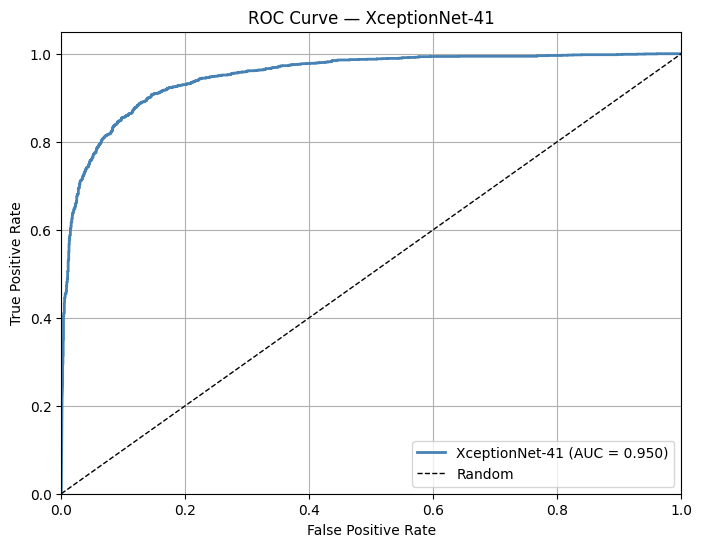

AUC (XceptionNet-41): 0.9496


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score,
                             f1_score, roc_curve, auc)
import torch

def to_float(x):
    return x.cpu().item() if isinstance(x, torch.Tensor) else float(x)

hist_xception41['train_acc'] = [to_float(a) for a in hist_xception41['train_acc']]
hist_xception41['val_acc']   = [to_float(a) for a in hist_xception41['val_acc']]

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(hist_xception41['train_loss'], label='Train Loss')
axes[0].plot(hist_xception41['val_loss'],   label='Val Loss')
axes[0].set_title('Loss — XceptionNet-41')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(hist_xception41['train_acc'], label='Train Acc')
axes[1].plot(hist_xception41['val_acc'],   label='Val Acc')
axes[1].set_title('Accuracy — XceptionNet-41')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True)

plt.suptitle('XceptionNet-41 Training History', fontsize=13)
plt.tight_layout(); plt.show()

# Test evaluation
model_xception41_ft.eval()
all_labels_xception41, all_preds_xception41 = [], []
print("\nEvaluating XceptionNet-41 on test dataset...")

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_xception41_ft(inputs)
        _, preds = torch.max(outputs, 1)
        all_labels_xception41.extend(labels.cpu().numpy())
        all_preds_xception41.extend(preds.cpu().numpy())

all_labels_xception41 = np.array(all_labels_xception41)
all_preds_xception41  = np.array(all_preds_xception41)

# Confusion matrix
cm_xception41 = confusion_matrix(all_labels_xception41, all_preds_xception41)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_xception41, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Confusion Matrix — XceptionNet-41'); plt.show()

# Metrics
accuracy_xception41  = accuracy_score(all_labels_xception41, all_preds_xception41)
precision_xception41 = precision_score(all_labels_xception41, all_preds_xception41, average='binary')
recall_xception41    = recall_score(all_labels_xception41, all_preds_xception41, average='binary')
f1_xception41        = f1_score(all_labels_xception41, all_preds_xception41, average='binary')

print(f"\nTest Accuracy  (XceptionNet-41): {accuracy_xception41:.4f}")
print(f"Test Precision (XceptionNet-41): {precision_xception41:.4f}")
print(f"Test Recall    (XceptionNet-41): {recall_xception41:.4f}")
print(f"Test F1-Score  (XceptionNet-41): {f1_xception41:.4f}")

# ROC
all_labels_roc_41, all_probs_roc_41 = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_xception41_ft(inputs)
        probs = torch.softmax(outputs, dim=1)
        all_labels_roc_41.extend(labels.cpu().numpy())
        all_probs_roc_41.extend(probs[:, 1].cpu().numpy())

fpr_xception41, tpr_xception41, _ = roc_curve(all_labels_roc_41, all_probs_roc_41)
roc_auc_xception41 = auc(fpr_xception41, tpr_xception41)

plt.figure(figsize=(8, 6))
plt.plot(fpr_xception41, tpr_xception41, color='steelblue', lw=2,
         label=f'XceptionNet-41 (AUC = {roc_auc_xception41:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
plt.xlim([0, 1]); plt.ylim([0, 1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — XceptionNet-41')
plt.legend(loc='lower right'); plt.grid(True); plt.show()
print(f"AUC (XceptionNet-41): {roc_auc_xception41:.4f}")


# XceptionNet-65 Model — Baseline Model 8

In [16]:
import timm
import torch
import torch.nn as nn
import torch.optim as optim

# ============================================================
# XCEPTION65 MODEL SETUP
# 65-layer variant — best accuracy/compute balance in the family
# Same 299×299 input — reuses existing train/val/test loaders
# ============================================================

print("Loading pretrained XceptionNet-65...")
model_xception65 = timm.create_model('xception65', pretrained=True)

# Freeze all layers first
for param in model_xception65.parameters():
    param.requires_grad = False

print("All XceptionNet-65 backbone layers frozen.")

# Unfreeze last 50 parameters (deeper model, more params to fine-tune)
all_params = list(model_xception65.parameters())
for i, param in enumerate(all_params):
    if i >= len(all_params) - 50:
        param.requires_grad = True

print("Unfrozen the last 50 parameters for fine-tuning.")

# Get classifier input features
num_ftrs_xception65 = model_xception65.num_features

# Same 3-layer classifier head
model_xception65.head.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(num_ftrs_xception65, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, 2)
)

for param in model_xception65.head.fc.parameters():
    param.requires_grad = True

print(f"Custom 3-layer head attached (in_features={num_ftrs_xception65}).")

criterion_xception65 = nn.CrossEntropyLoss()
optimizer_xception65 = optim.Adam(
    filter(lambda p: p.requires_grad, model_xception65.parameters()),
    lr=0.0001
)

model_xception65 = model_xception65.to(device)
print(f"XceptionNet-65 moved to: {device}")

trainable = sum(p.numel() for p in model_xception65.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_xception65.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")


Loading pretrained XceptionNet-65...


model.safetensors:   0%|          | 0.00/160M [00:00<?, ?B/s]

All XceptionNet-65 backbone layers frozen.
Unfrozen the last 50 parameters for fine-tuning.
Custom 3-layer head attached (in_features=2048).
XceptionNet-65 moved to: cuda:0
Trainable params: 12,423,466 / 38,982,322 (31.9%)


In [17]:
print("\n--- Starting XceptionNet-65 Training ---")

model_xception65_ft, hist_xception65 = train_model(
    model_xception65,
    criterion_xception65,
    optimizer_xception65,
    train_loader,
    val_loader,
    num_epochs=30,
    patience=5,
    save_path="best_xception65.pth"
)

print("\nTraining complete for XceptionNet-65.")
print("Best model saved to: best_xception65.pth")


--- Starting XceptionNet-65 Training ---
Epoch 1/30
----------
train Loss: 0.5483 Acc: 0.7051
val Loss: 0.5958 Acc: 0.8082
Best model saved.
Epoch 2/30
----------
train Loss: 0.3919 Acc: 0.8201
val Loss: 0.4803 Acc: 0.8311
Best model saved.
Epoch 3/30
----------
train Loss: 0.3111 Acc: 0.8643
val Loss: 0.4701 Acc: 0.8456
Best model saved.
Epoch 4/30
----------
train Loss: 0.2682 Acc: 0.8870
val Loss: 0.7192 Acc: 0.8391
Epoch 5/30
----------
train Loss: 0.2371 Acc: 0.9024
val Loss: 1.0726 Acc: 0.8604
Best model saved.
Epoch 6/30
----------
train Loss: 0.2107 Acc: 0.9140
val Loss: 0.4967 Acc: 0.8698
Best model saved.
Epoch 7/30
----------
train Loss: 0.1933 Acc: 0.9211
val Loss: 0.6827 Acc: 0.8740
Best model saved.
Epoch 8/30
----------
train Loss: 0.1738 Acc: 0.9290
val Loss: 0.7974 Acc: 0.8487
Epoch 9/30
----------
train Loss: 0.1647 Acc: 0.9351
val Loss: 1.2385 Acc: 0.8349
Epoch 10/30
----------
train Loss: 0.1509 Acc: 0.9411
val Loss: 0.6571 Acc: 0.8344
Epoch 11/30
----------
train 

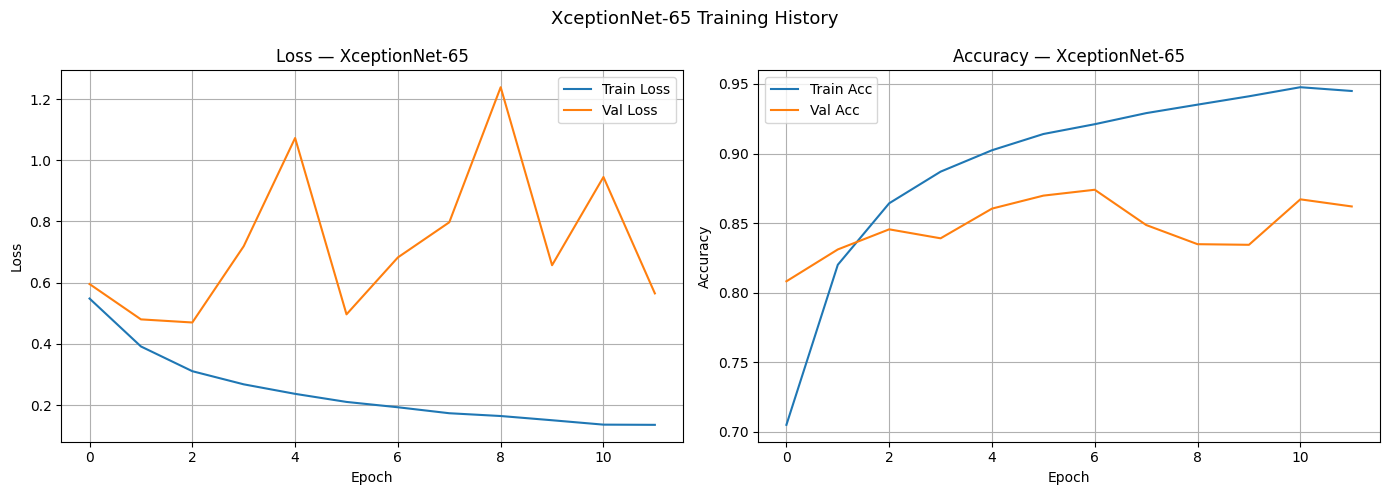


Evaluating XceptionNet-65 on test dataset...


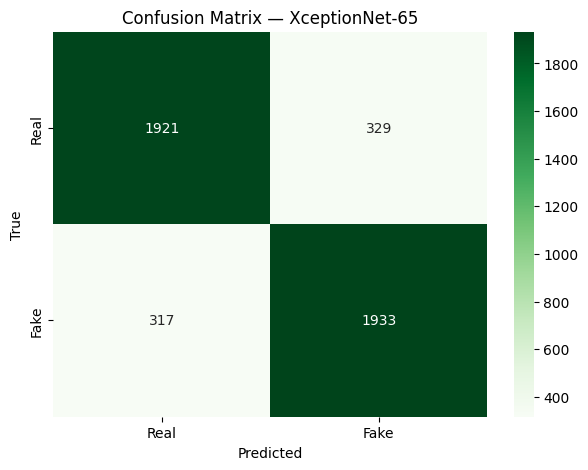


Test Accuracy  (XceptionNet-65): 0.8564
Test Precision (XceptionNet-65): 0.8546
Test Recall    (XceptionNet-65): 0.8591
Test F1-Score  (XceptionNet-65): 0.8568


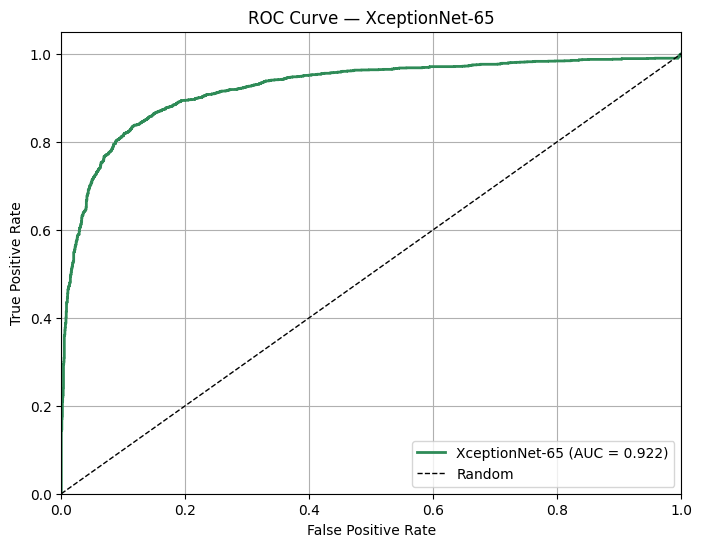

AUC (XceptionNet-65): 0.9220


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score,
                             f1_score, roc_curve, auc)
import torch

hist_xception65['train_acc'] = [to_float(a) for a in hist_xception65['train_acc']]
hist_xception65['val_acc']   = [to_float(a) for a in hist_xception65['val_acc']]

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(hist_xception65['train_loss'], label='Train Loss')
axes[0].plot(hist_xception65['val_loss'],   label='Val Loss')
axes[0].set_title('Loss — XceptionNet-65')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(hist_xception65['train_acc'], label='Train Acc')
axes[1].plot(hist_xception65['val_acc'],   label='Val Acc')
axes[1].set_title('Accuracy — XceptionNet-65')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True)

plt.suptitle('XceptionNet-65 Training History', fontsize=13)
plt.tight_layout(); plt.show()

# Test evaluation
model_xception65_ft.eval()
all_labels_xception65, all_preds_xception65 = [], []
print("\nEvaluating XceptionNet-65 on test dataset...")

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_xception65_ft(inputs)
        _, preds = torch.max(outputs, 1)
        all_labels_xception65.extend(labels.cpu().numpy())
        all_preds_xception65.extend(preds.cpu().numpy())

all_labels_xception65 = np.array(all_labels_xception65)
all_preds_xception65  = np.array(all_preds_xception65)

cm_xception65 = confusion_matrix(all_labels_xception65, all_preds_xception65)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_xception65, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Confusion Matrix — XceptionNet-65'); plt.show()

accuracy_xception65  = accuracy_score(all_labels_xception65, all_preds_xception65)
precision_xception65 = precision_score(all_labels_xception65, all_preds_xception65, average='binary')
recall_xception65    = recall_score(all_labels_xception65, all_preds_xception65, average='binary')
f1_xception65        = f1_score(all_labels_xception65, all_preds_xception65, average='binary')

print(f"\nTest Accuracy  (XceptionNet-65): {accuracy_xception65:.4f}")
print(f"Test Precision (XceptionNet-65): {precision_xception65:.4f}")
print(f"Test Recall    (XceptionNet-65): {recall_xception65:.4f}")
print(f"Test F1-Score  (XceptionNet-65): {f1_xception65:.4f}")

all_labels_roc_65, all_probs_roc_65 = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_xception65_ft(inputs)
        probs = torch.softmax(outputs, dim=1)
        all_labels_roc_65.extend(labels.cpu().numpy())
        all_probs_roc_65.extend(probs[:, 1].cpu().numpy())

fpr_xception65, tpr_xception65, _ = roc_curve(all_labels_roc_65, all_probs_roc_65)
roc_auc_xception65 = auc(fpr_xception65, tpr_xception65)

plt.figure(figsize=(8, 6))
plt.plot(fpr_xception65, tpr_xception65, color='seagreen', lw=2,
         label=f'XceptionNet-65 (AUC = {roc_auc_xception65:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
plt.xlim([0, 1]); plt.ylim([0, 1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — XceptionNet-65')
plt.legend(loc='lower right'); plt.grid(True); plt.show()
print(f"AUC (XceptionNet-65): {roc_auc_xception65:.4f}")
